In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
combined_data = pd.read_csv(r'../data/cleaned_campaign_data.csv')

A) Brand Analysis     → Nykaa vs Purplle vs Tira
B) Campaign Type      → which type performs best
C) Channel Analysis   → which platform wins
D) Audience Analysis  → who converts best
E) Correlation        → how numbers relate
F) Time Trends        → monthly patterns
G) All of the above   → full EDA in order

# Brand Analysis

In [10]:
#Setting style for charts
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

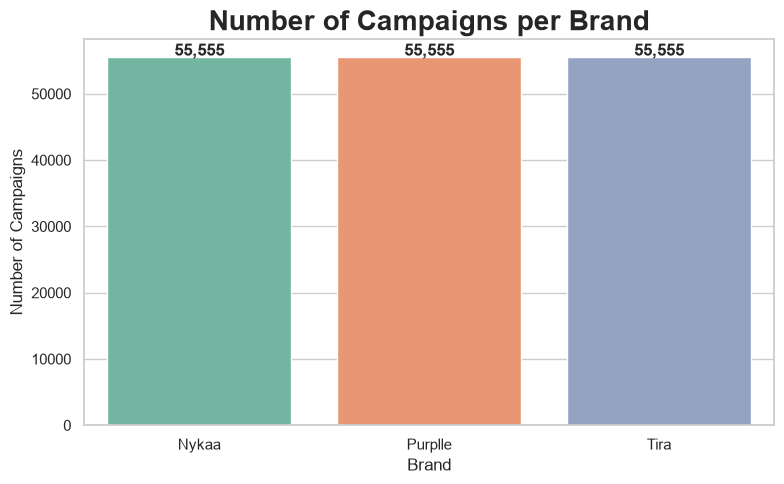

In [11]:
# Number of Campaigns per Brand
plt.figure(figsize=(8, 5 ))
brand_counts =combined_data['Brand'].value_counts()

sns.barplot(x=brand_counts.index, 
            y=brand_counts.values, 
            hue=brand_counts.index,    # ← add this
            palette='Set2', 
            legend=False) 
plt.title('Number of Campaigns per Brand', fontsize=20, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Number of Campaigns')
for i, v in  enumerate(brand_counts.values):
    plt.text(i,v+200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

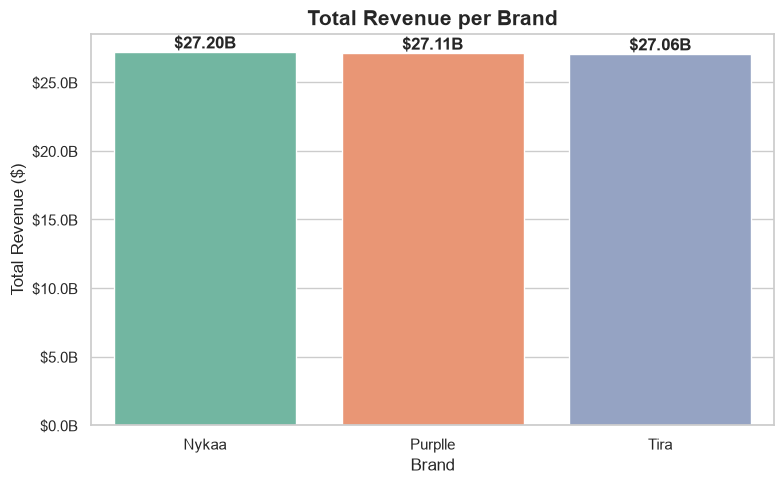


Total Revenue per Brand:
Brand
Nykaa      $27.20B
Purplle    $27.11B
Tira       $27.06B
Name: Revenue, dtype: str


In [12]:
# Total Revenue per Brand
fig, ax = plt.subplots(figsize=(8, 5))
brand_revenue = combined_data.groupby('Brand')['Revenue'].sum().sort_values(ascending=False)

sns.barplot(x=brand_revenue.index, 
            y=brand_revenue.values, 
            hue=brand_revenue.index,
            palette='Set2', 
            legend=False)

plt.title('Total Revenue per Brand', fontsize=15, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Total Revenue ($)')

# Format y-axis to show Billions automatically
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

# Labels on top of bars
for i, v in enumerate(brand_revenue.values):
    plt.text(i, v * 1.01, f'${v/1e9:.2f}B', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTotal Revenue per Brand:")
print(brand_revenue.apply(lambda x: f'${x/1e9:.2f}B'))

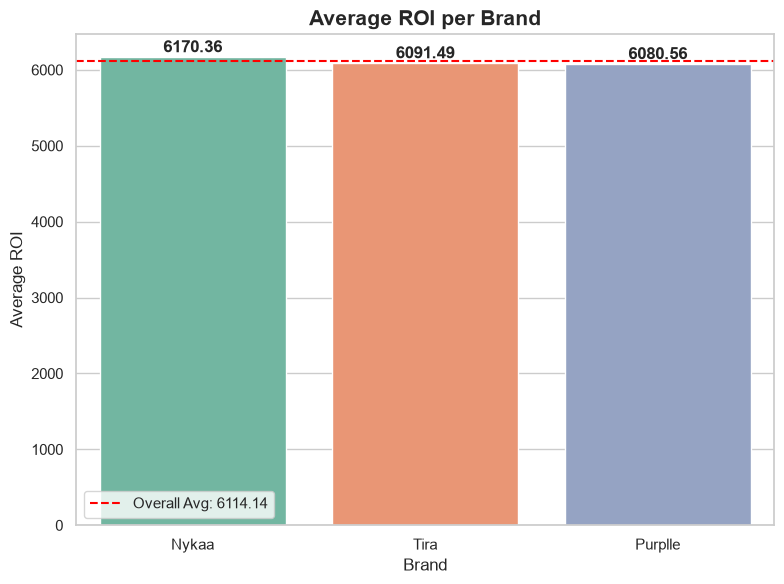


Average ROI per Brand:
Brand
Nykaa      6170.36
Tira       6091.49
Purplle    6080.56
Name: Updated_ROI, dtype: float64


In [13]:
# Average ROI per Brand

fig,ax = plt.subplots(figsize=(8,6))
brand_roi = combined_data.groupby('Brand')['Updated_ROI'].mean().sort_values(ascending=False)
sns.barplot(x=brand_roi.index, 
            y=brand_roi.values, 
            hue=brand_roi.index,
            palette='Set2', 
            legend=False,
            ax=ax)

ax.set_title('Average ROI per Brand', fontsize=15, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Average ROI')

ax.axhline(y=brand_roi.mean(), color='red', linestyle='--', 
           label=f'Overall Avg: {brand_roi.mean():.2f}')
ax.legend()
for i, v in enumerate(brand_roi.values):
    ax.text(i, v * 1.01, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage ROI per Brand:")
print(brand_roi.round(2))

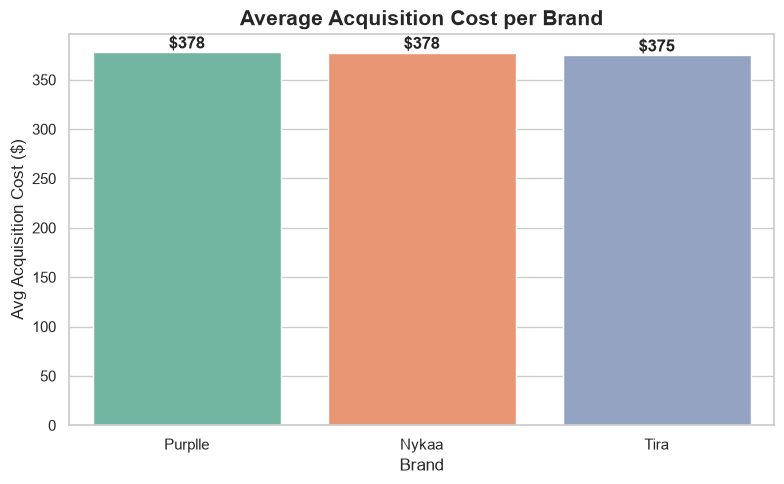


Average Acquisition Cost per Brand:
Brand
Purplle    377.99
Nykaa      377.59
Tira       374.92
Name: Acquisition_Cost, dtype: float64


In [14]:
# Average Acquisition Cost per Brand
fig, ax = plt.subplots(figsize=(8, 5))

brand_cost = combined_data.groupby('Brand')['Acquisition_Cost'].mean().sort_values(ascending=False)

sns.barplot(x=brand_cost.index, 
            y=brand_cost.values, 
            hue=brand_cost.index,
            palette='Set2', 
            legend=False,
            ax=ax)

ax.set_title('Average Acquisition Cost per Brand', fontsize=15, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Avg Acquisition Cost ($)')

for i, v in enumerate(brand_cost.values):
    ax.text(i, v * 1.01, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage Acquisition Cost per Brand:")
print(brand_cost.round(2))

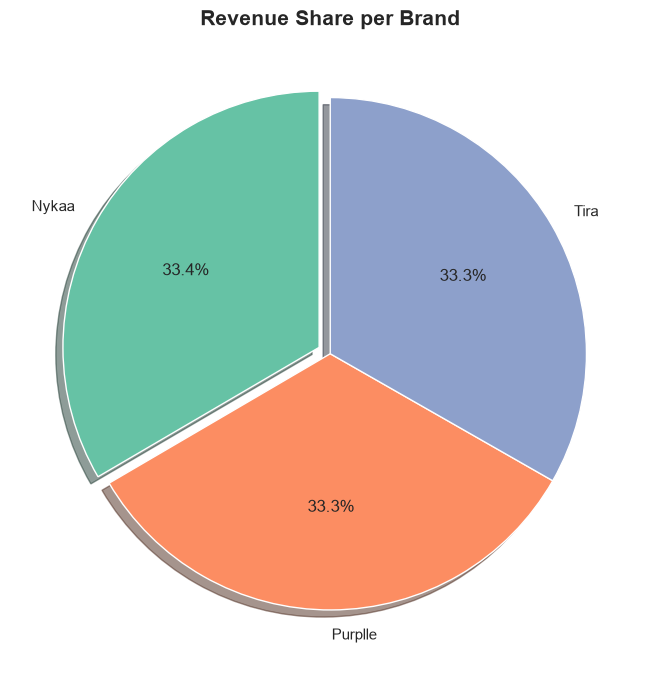

In [15]:
# Revenue Share per Brand
fig, ax = plt.subplots(figsize=(7, 7))

brand_revenue = combined_data.groupby('Brand')['Revenue'].sum()

ax.pie(brand_revenue.values, 
       labels=brand_revenue.index,
       autopct='%1.1f%%',        # show percentage on each slice
       startangle=90,            # start from top
       colors=['#66c2a5','#fc8d62','#8da0cb'],
       explode=(0.05, 0, 0),     # slightly pull out first slice
       shadow=True)

ax.set_title('Revenue Share per Brand', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Campaign Type Analysis

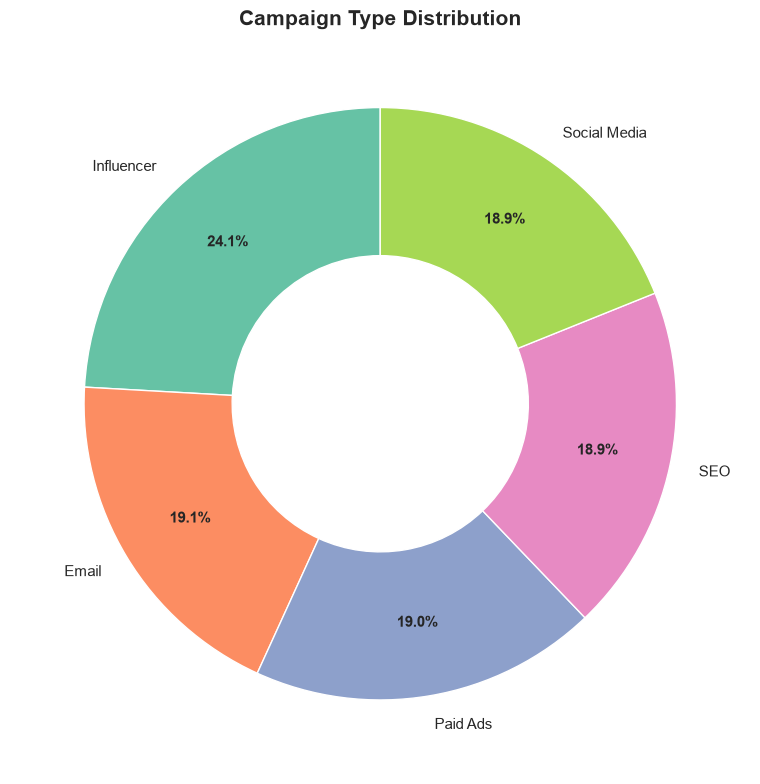

Campaign_Type
Influencer      40175
Email           31801
Paid Ads        31604
SEO             31570
Social Media    31515
Name: count, dtype: int64


In [16]:
#  Campaign Type Distribution which type is used most 
fig, ax = plt.subplots(figsize=(8, 8))

campaign_counts = combined_data['Campaign_Type'].value_counts()

wedges, texts, autotexts = ax.pie(
    campaign_counts.values,
    labels=campaign_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(campaign_counts)),
    wedgeprops=dict(width=0.5),   # ← this makes it a DONUT
    pctdistance=0.75
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title('Campaign Type Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(campaign_counts)

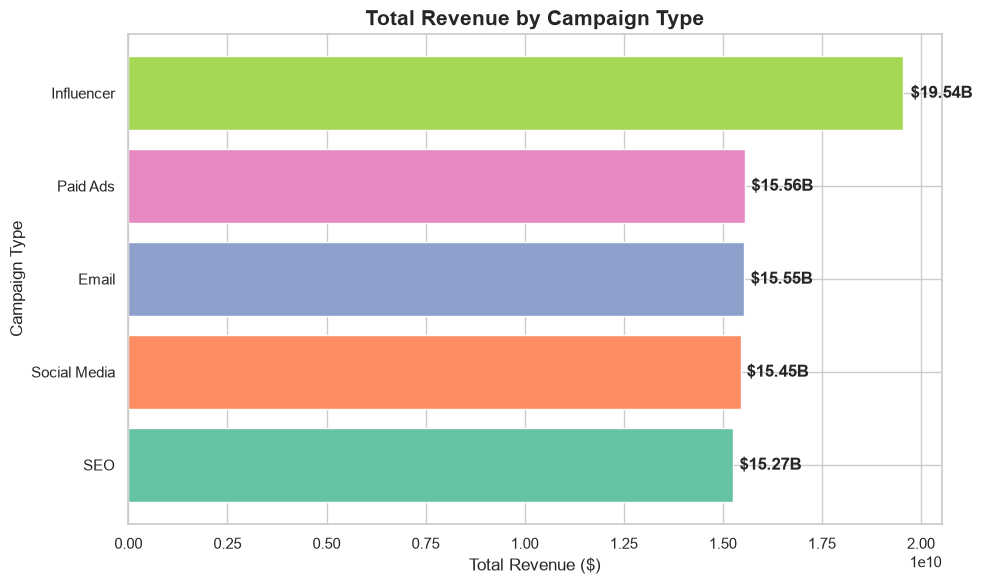


Revenue by Campaign Type:
Campaign_Type
SEO             $15.27B
Social Media    $15.45B
Email           $15.55B
Paid Ads        $15.56B
Influencer      $19.54B
Name: Revenue, dtype: str


In [17]:
# Revenue by Campaign Type (Horizontal Bar)
fig, ax = plt.subplots(figsize=(10, 6))

campaign_revenue = combined_data.groupby('Campaign_Type')['Revenue'].sum().sort_values()

# Horizontal bar chart → better for category names
ax.barh(campaign_revenue.index,
        campaign_revenue.values,
        color=sns.color_palette('Set2', len(campaign_revenue)))

ax.set_title('Total Revenue by Campaign Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Campaign Type')

# Add value labels at end of each bar
for i, v in enumerate(campaign_revenue.values):
    ax.text(v * 1.01, i, f'${v/1e9:.2f}B', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRevenue by Campaign Type:")
print(campaign_revenue.apply(lambda x: f'${x/1e9:.2f}B'))

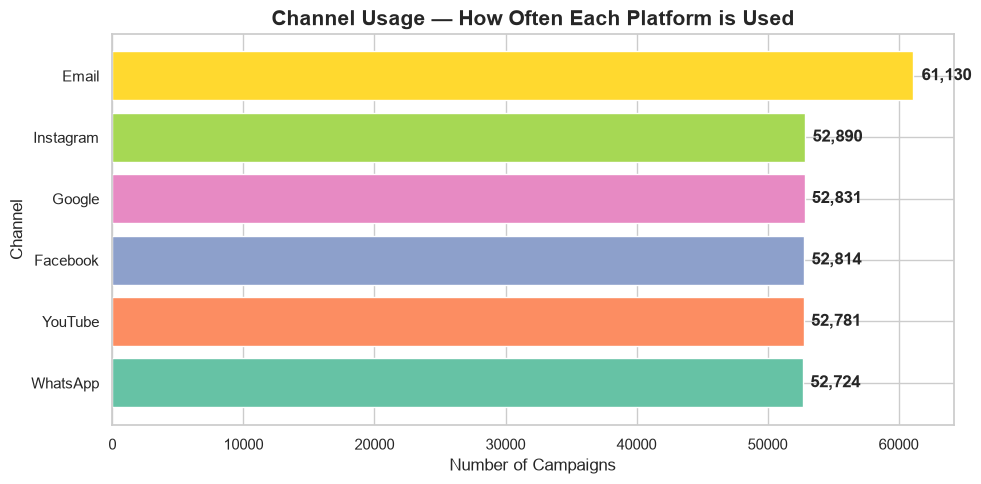


Channel Usage:
Email        61130
Instagram    52890
Google       52831
Facebook     52814
YouTube      52781
WhatsApp     52724
dtype: int64


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

channel_cols = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']
channel_usage = combined_data[channel_cols].sum().sort_values()

ax.barh(channel_usage.index,
        channel_usage.values,
        color=sns.color_palette('Set2', len(channel_usage)))

ax.set_title('Channel Usage — How Often Each Platform is Used',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Campaigns')
ax.set_ylabel('Channel')

for i, v in enumerate(channel_usage.values):
    ax.text(v * 1.01, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nChannel Usage:")
print(channel_usage.sort_values(ascending=False))

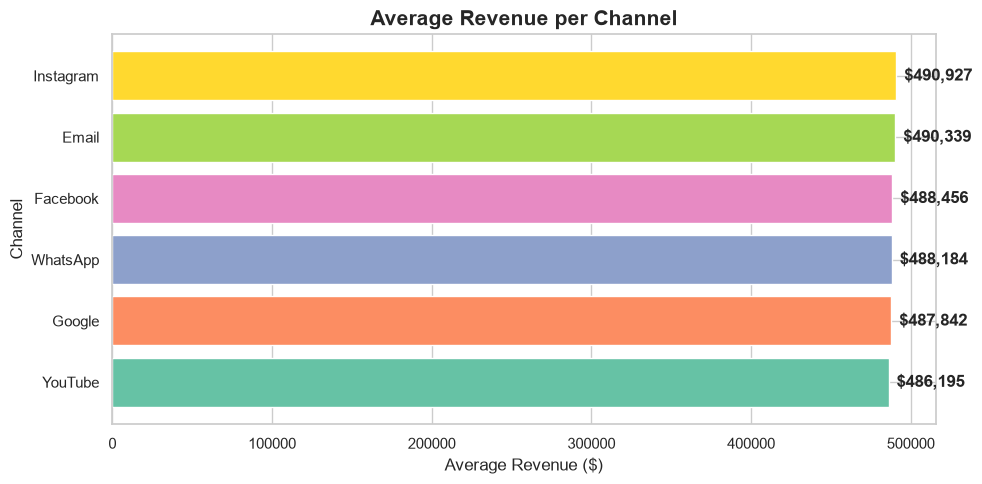


Average Revenue per Channel:
Instagram    $490,927
Email        $490,339
Facebook     $488,456
WhatsApp     $488,184
Google       $487,842
YouTube      $486,195
dtype: str


In [19]:
#Revenue per Channel
fig, ax = plt.subplots(figsize=(10, 5))

channel_revenue = {}
for ch in channel_cols:
    # Filter rows where this channel was used (=1) and sum revenue
    channel_revenue[ch] = combined_data[combined_data[ch] == 1]['Revenue'].mean()

channel_revenue = pd.Series(channel_revenue).sort_values()

ax.barh(channel_revenue.index,
        channel_revenue.values,
        color=sns.color_palette('Set2', len(channel_revenue)))

ax.set_title('Average Revenue per Channel',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Average Revenue ($)')
ax.set_ylabel('Channel')

for i, v in enumerate(channel_revenue.values):
    ax.text(v * 1.01, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage Revenue per Channel:")
print(channel_revenue.sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

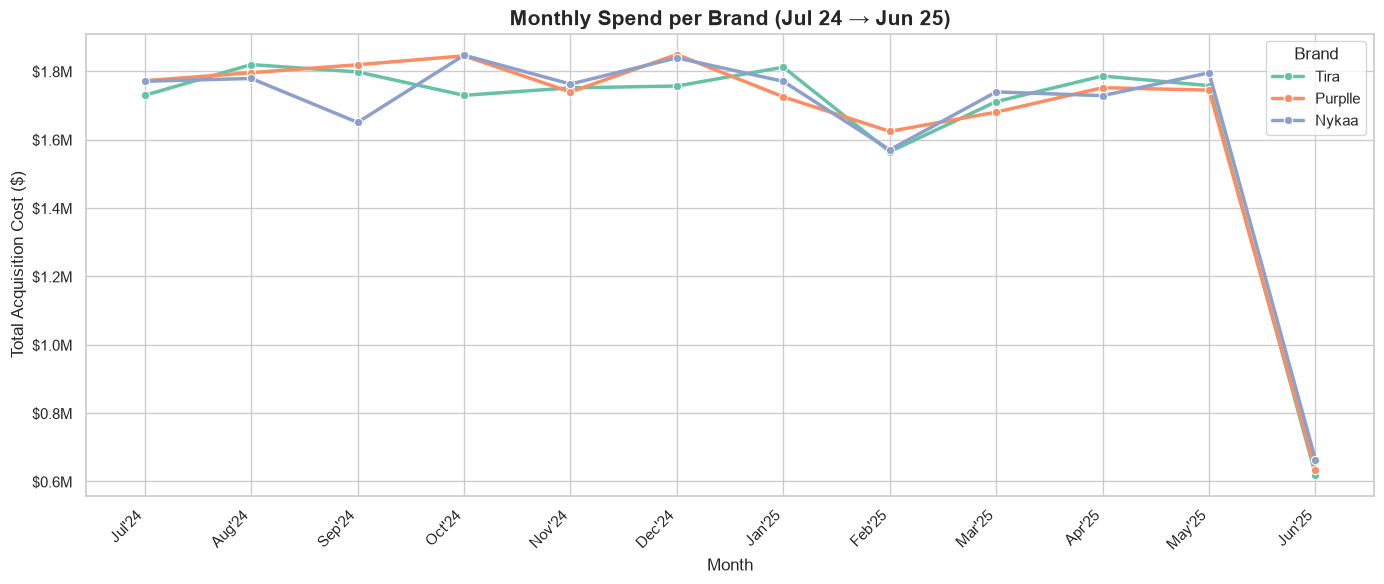


Monthly Spend per Brand ($ Millions):
Brand       Nykaa  Purplle  Tira  Total
Month_Name                             
Dec'24       1.84     1.85  1.76   5.44
Oct'24       1.85     1.84  1.73   5.42
Aug'24       1.78     1.80  1.82   5.39
Jan'25       1.77     1.73  1.81   5.31
May'25       1.80     1.74  1.76   5.30
Jul'24       1.77     1.77  1.73   5.27
Sep'24       1.65     1.82  1.80   5.27
Apr'25       1.73     1.75  1.79   5.27
Nov'24       1.76     1.74  1.75   5.25
Mar'25       1.74     1.68  1.71   5.13
Feb'25       1.57     1.62  1.56   4.76
Jun'25       0.66     0.63  0.62   1.92


In [20]:
# Each Brand's Spend per Month_Name
fig, ax = plt.subplots(figsize=(14, 6))

brand_monthly_spend = combined_data.groupby(
    ['Month_Name', 'Brand'])['Acquisition_Cost'].sum().reset_index()

month_order = ["Jul'24","Aug'24","Sep'24","Oct'24","Nov'24","Dec'24",
               "Jan'25","Feb'25","Mar'25","Apr'25","May'25","Jun'25"]

brand_monthly_spend['Month_Name'] = pd.Categorical(
    brand_monthly_spend['Month_Name'],
    categories=month_order,
    ordered=True)

brand_monthly_spend = brand_monthly_spend.sort_values('Month_Name')

sns.lineplot(data=brand_monthly_spend,
             x='Month_Name',
             y='Acquisition_Cost',
             hue='Brand',
             palette='Set2',
             linewidth=2.5,
             marker='o',
             ax=ax)

ax.set_title('Monthly Spend per Brand (Jul 24 → Jun 25)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Acquisition Cost ($)')

# ← fix: use ax.tick_params instead of set_xticklabels
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order, rotation=45, ha='right')

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax.legend(title='Brand')
plt.tight_layout()
plt.show()

print("\nMonthly Spend per Brand ($ Millions):")
pivot = brand_monthly_spend.pivot(index='Month_Name', 
                                   columns='Brand', 
                                   values='Acquisition_Cost')

# Add Total column
pivot['Total'] = pivot.sum(axis=1)

# Sort by Total highest to lowest
pivot = pivot.sort_values('Total', ascending=False)

# Display in millions
print((pivot/1e6).round(2))

Finding :
according to this chart june as lowes as it is the holiday month and costomatic use is les  and christmas mounts  december is higest  as it has christmas and nuwear in end 

In [ ]:
# Each Brand's Spend per Channel
fig, ax = plt.subplots(figsize=(12, 6))

channel_cols = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']

# For each channel, filter rows where channel=1, group by Brand, sum cost
records = []
for ch in channel_cols:
    temp = combined_data[combined_data[ch] == 1].groupby('Brand')['Acquisition_Cost'].sum()
    for brand, val in temp.items():
        records.append({'Channel': ch, 'Brand': brand, 'Spend': val})

channel_brand_spend = pd.DataFrame(records)

sns.barplot(data=channel_brand_spend,
            x='Channel',
            y='Spend',
            hue='Brand',
            palette='Set2',
            ax=ax)

ax.set_title('Brand Spend per Channel',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Total Acquisition Cost ($)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.legend(title='Brand')

plt.tight_layout()
plt.show()

print("\nBrand Spend per Channel ($ Millions):")
pivot2 = channel_brand_spend.pivot_table(index='Channel', 
                                          columns='Brand', 
                                          values='Spend')
print((pivot2/1e6).round(2))

Finding :
Brand spend most of the amount on emails my suggestion should be focus on Youtube and instarahram as it covers may people intrested to costmatics 

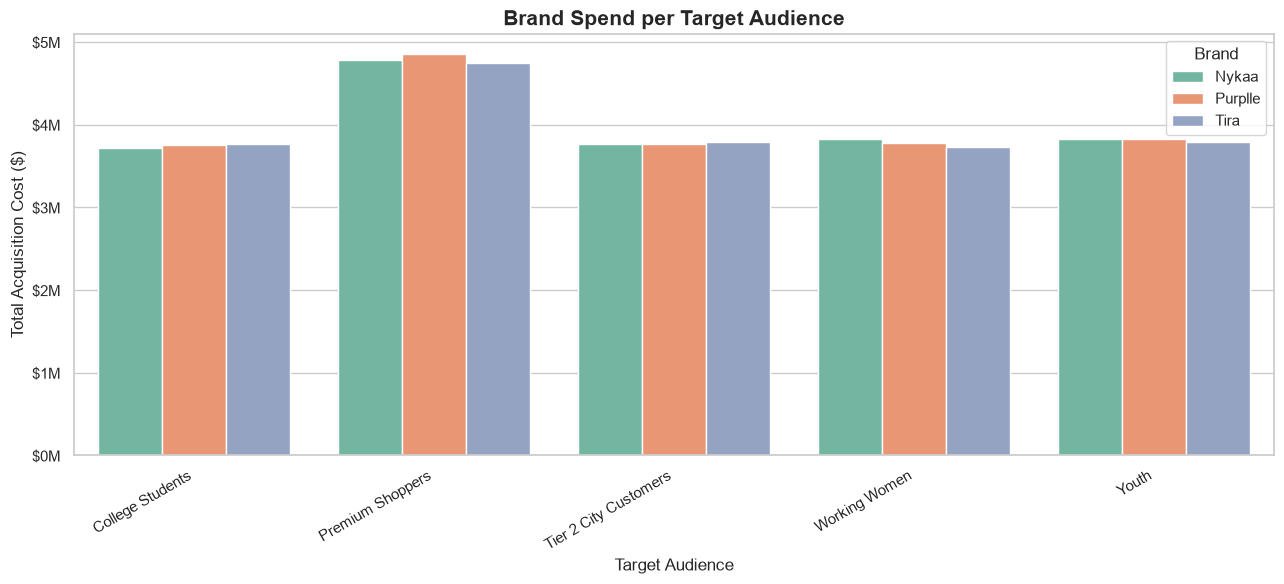


Brand Spend per Target Audience ($ Millions):
Brand                  Nykaa  Purplle  Tira  Total
Target_Audience                                   
Premium Shoppers        4.78     4.86  4.75  14.38
Youth                   3.83     3.82  3.79  11.44
Working Women           3.82     3.78  3.73  11.34
Tier 2 City Customers   3.76     3.76  3.80  11.32
College Students        3.72     3.76  3.76  11.24


In [21]:
fig, ax = plt.subplots(figsize=(13, 6))

brand_audience_spend = combined_data.groupby(
    ['Target_Audience', 'Brand'])['Acquisition_Cost'].sum().reset_index()

sns.barplot(data=brand_audience_spend,
            x='Target_Audience',
            y='Acquisition_Cost',
            hue='Brand',
            palette='Set2',
            ax=ax)

ax.set_title('Brand Spend per Target Audience',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Target Audience')
ax.set_ylabel('Total Acquisition Cost ($)')

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# ← Fix: use plt.xticks() instead of ax.set_xticklabels()
plt.xticks(rotation=30, ha='right')

ax.legend(title='Brand')
plt.tight_layout()
plt.show()

print("\nBrand Spend per Target Audience ($ Millions):")
pivot3 = brand_audience_spend.pivot_table(
    index='Target_Audience',
    columns='Brand',
    values='Acquisition_Cost')
pivot3['Total'] = pivot3.sum(axis=1)
pivot3 = pivot3.sort_values('Total', ascending=False)
print((pivot3/1e6).round(2))


Findings: 
Brand focus more om premier  shopers , i would suggested to alos focus on working womens and college student with offeres and rewards that can be used in brad for next sghopping  so they will stay in loop 

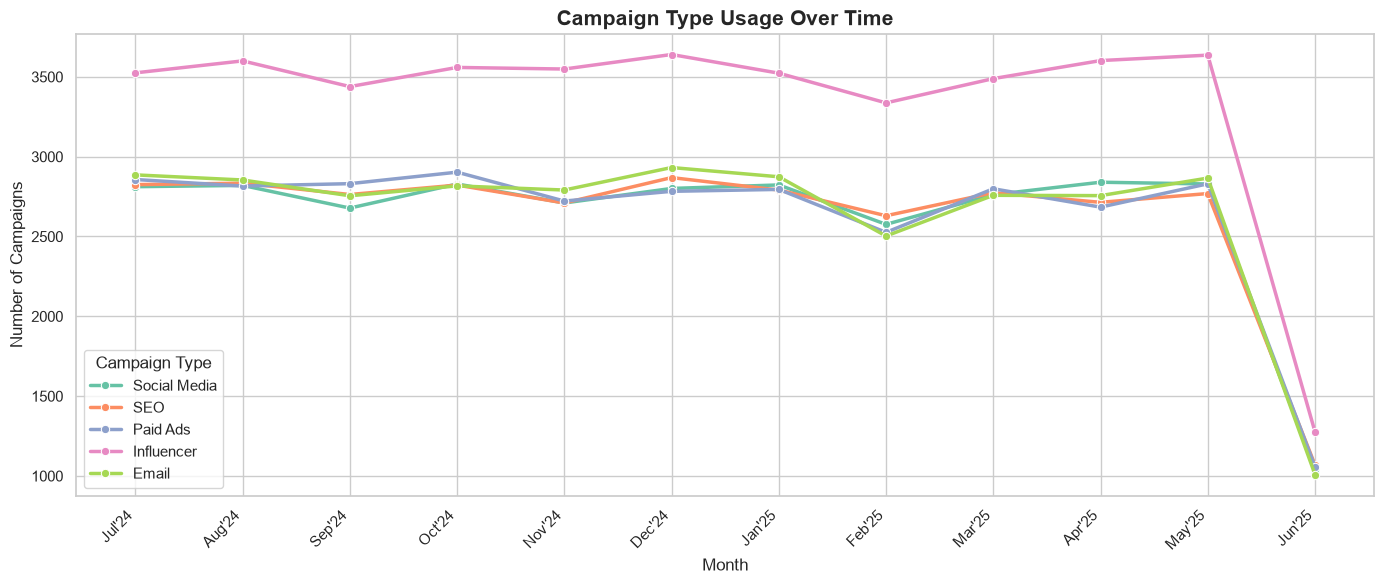

In [22]:
#Time Trends:
fig, ax = plt.subplots(figsize=(14, 6))

monthly_campaign = combined_data.groupby(
    ['Month_Name', 'Campaign_Type']).size().reset_index(name='Count')

monthly_campaign['Month_Name'] = pd.Categorical(
    monthly_campaign['Month_Name'],
    categories=month_order,
    ordered=True)

monthly_campaign = monthly_campaign.sort_values('Month_Name')

sns.lineplot(data=monthly_campaign,
             x='Month_Name',
             y='Count',
             hue='Campaign_Type',
             palette='Set2',
             linewidth=2.5,
             marker='o',
             ax=ax)

ax.set_title('Campaign Type Usage Over Time',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Campaigns')

plt.xticks(rotation=45, ha='right')
ax.legend(title='Campaign Type')
plt.tight_layout()
plt.show()

In [23]:
#Fixing the outliers
# First let's SEE the outliers in our key columns
numerical_cols = ['Revenue', 'Updated_ROI', 'Impressions', 
                  'Clicks', 'Leads', 'Conversions', 
                  'Acquisition_Cost', 'Engagement_Score', 'Duration']

print("═══ OUTLIER ANALYSIS ═══\n")
for col in numerical_cols:
    Q1  = combined_data[col].quantile(0.25)
    Q3  = combined_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    
    outliers = combined_data[
        (combined_data[col] < lower) | 
        (combined_data[col] > upper)
    ]
    
    pct = len(outliers) / len(combined_data) * 100
    
    print(f"{col:20} → outliers: {len(outliers):6,} ({pct:.1f}%)"
          f"  |  min: {combined_data[col].min():.1f}"
          f"  max: {combined_data[col].max():.1f}"
          f"  upper fence: {upper:.1f}")

═══ OUTLIER ANALYSIS ═══

Revenue              → outliers:  9,415 (5.6%)  |  min: 0.0  max: 4579910.0  upper fence: 1416888.0
Updated_ROI          → outliers: 18,295 (11.0%)  |  min: -1.0  max: 494114.4  upper fence: 13749.1
Impressions          → outliers:      0 (0.0%)  |  min: 10001.0  max: 100000.0  upper fence: 140393.0
Clicks               → outliers:  1,885 (1.1%)  |  min: 202.0  max: 14944.0  upper fence: 12997.5
Leads                → outliers:  6,184 (3.7%)  |  min: 48.0  max: 8876.0  upper fence: 5099.0
Conversions          → outliers:  8,079 (4.8%)  |  min: 17.0  max: 6686.0  upper fence: 2767.0
Acquisition_Cost     → outliers: 13,832 (8.3%)  |  min: 8.2  max: 15473.2  upper fence: 911.3
Engagement_Score     → outliers:      0 (0.0%)  |  min: 2.6  max: 31.0  upper fence: 33.4
Duration             → outliers:      0 (0.0%)  |  min: 5.0  max: 30.0  upper fence: 43.5


In [24]:
# We use PERCENTILE CAPPING (Winsorization)
# Cap at 1st percentile (lower) and 99th percentile (upper)
# Values outside this range get pulled to the boundary

cols_to_cap = ['Revenue', 'Updated_ROI', 'Clicks', 
               'Leads', 'Conversions', 'Acquisition_Cost']

print("═══ CAPPING OUTLIERS ═══\n")

for col in cols_to_cap:
    # Calculate 1st and 99th percentile
    lower_cap = combined_data[col].quantile(0.01)
    upper_cap = combined_data[col].quantile(0.99)
    
    # Count outliers before
    before = len(combined_data[
        (combined_data[col] < lower_cap) | 
        (combined_data[col] > upper_cap)
    ])
    
    # Cap the values
    # clip() → values below lower_cap → become lower_cap
    #          values above upper_cap → become upper_cap
    #          values in between      → unchanged ✅
    combined_data[col] = combined_data[col].clip(
        lower=lower_cap, 
        upper=upper_cap
    )
    
    # Count outliers after
    after = len(combined_data[
        (combined_data[col] < lower_cap) | 
        (combined_data[col] > upper_cap)
    ])
    
    print(f"✅ {col:20}")
    print(f"   Lower cap : {lower_cap:.2f}")
    print(f"   Upper cap : {upper_cap:.2f}")
    print(f"   Before    : {before:,} outliers")
    print(f"   After     : {after:,} outliers")
    print(f"   New range : {combined_data[col].min():.2f} → {combined_data[col].max():.2f}")
    print()

═══ CAPPING OUTLIERS ═══

✅ Revenue             
   Lower cap : 0.00
   Upper cap : 2302558.72
   Before    : 1,667 outliers
   After     : 0 outliers
   New range : 0.00 → 2302558.72

✅ Updated_ROI         
   Lower cap : -1.00
   Upper cap : 66861.13
   Before    : 1,586 outliers
   After     : 0 outliers
   New range : -1.00 → 66861.13

✅ Clicks              
   Lower cap : 459.00
   Upper cap : 13107.72
   Before    : 3,327 outliers
   After     : 0 outliers
   New range : 459.00 → 13107.72

✅ Leads               
   Lower cap : 156.00
   Upper cap : 6358.36
   Before    : 3,330 outliers
   After     : 0 outliers
   New range : 156.00 → 6358.36

✅ Conversions         
   Lower cap : 76.00
   Upper cap : 3946.36
   Before    : 3,333 outliers
   After     : 0 outliers
   New range : 76.00 → 3946.36

✅ Acquisition_Cost    
   Lower cap : 24.85
   Upper cap : 2609.73
   Before    : 3,171 outliers
   After     : 0 outliers
   New range : 24.85 → 2609.73



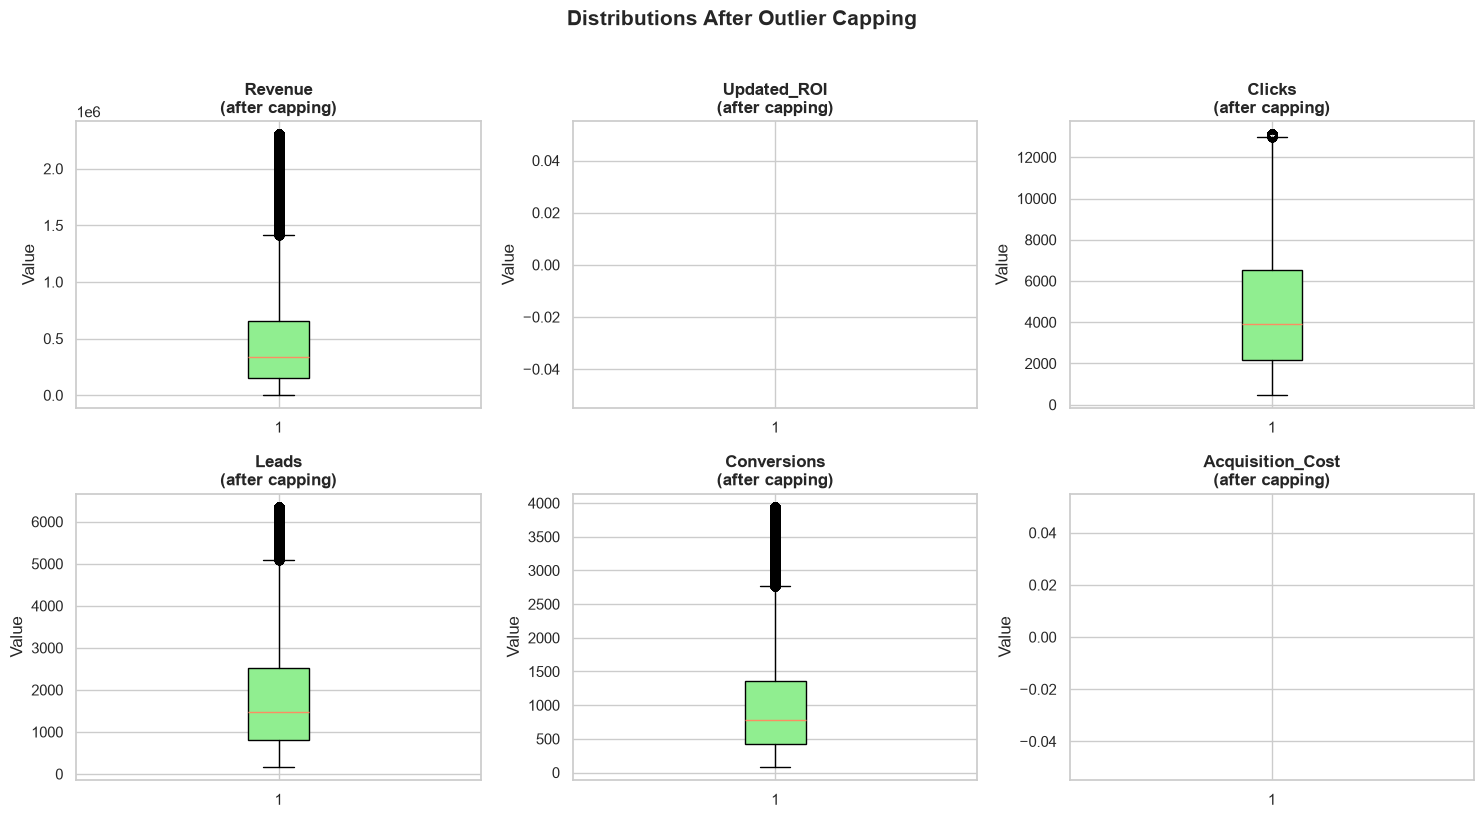


═══ FINAL STATS AFTER CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    158504.00  166665.00  166665.00    166665.00   
mean    483674.51      5736.48    4641.54    1847.10      1010.75   
std     467066.19     10919.09    3083.87    1374.91       814.46   
min          0.00        -1.00     459.00     156.00        76.00   
25%     154583.00       336.80    2185.00     809.00       417.00   
50%     335780.00      1547.82    3908.00    1476.00       775.00   
75%     659505.00      5701.70    6510.00    2525.00      1357.00   
max    2302558.72     66861.13   13107.72    6358.36      3946.36   

       Acquisition_Cost  
count         158504.00  
mean             364.40  
std              442.99  
min               24.85  
25%              106.76  
50%              208.72  
75%              428.56  
max             2609.73  


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_cap):
    axes[i].boxplot(combined_data[col], 
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{col}\n(after capping)', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Distributions After Outlier Capping', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n═══ FINAL STATS AFTER CAPPING ═══")
print(combined_data[cols_to_cap].describe().round(2))

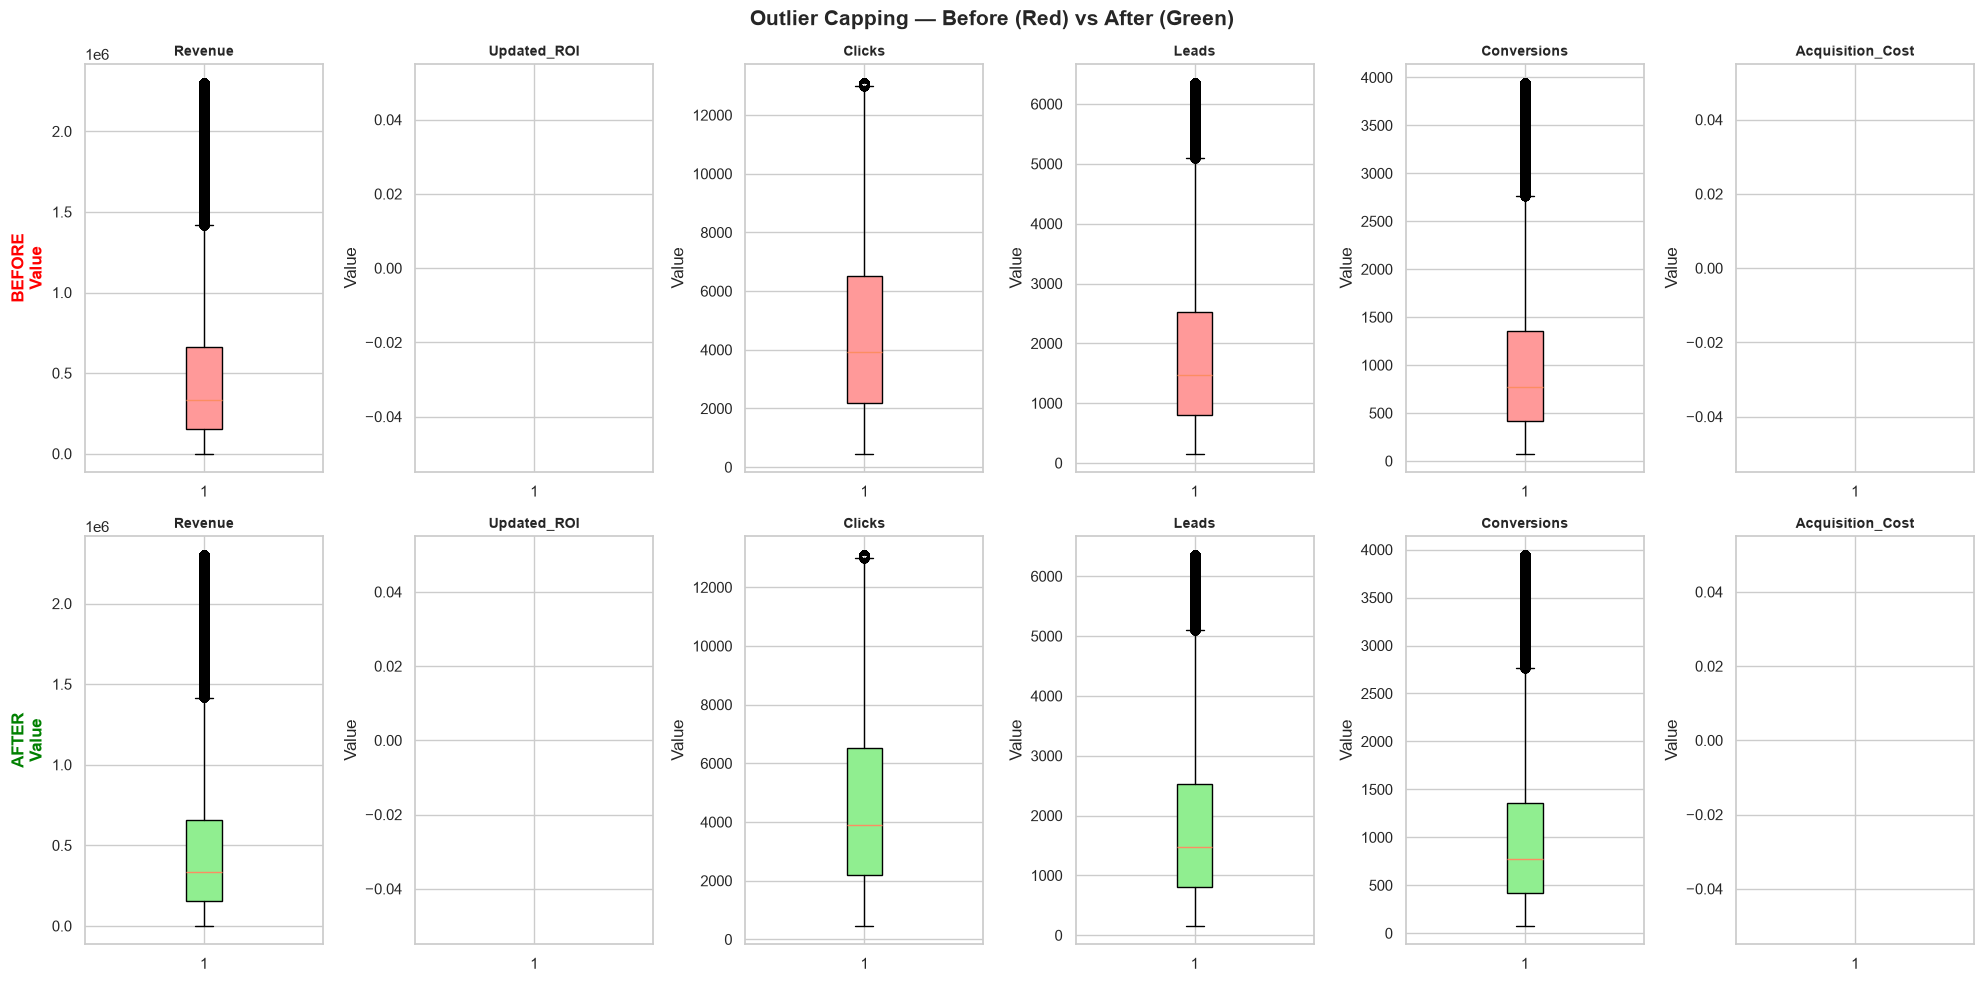

═══ BEFORE CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    158504.00  166665.00  166665.00    166665.00   
mean    483674.51      5736.48    4641.54    1847.10      1010.75   
std     467066.19     10919.09    3083.87    1374.91       814.46   
min          0.00        -1.00     459.00     156.00        76.00   
25%     154583.00       336.80    2185.00     809.00       417.00   
50%     335780.00      1547.82    3908.00    1476.00       775.00   
75%     659505.00      5701.70    6510.00    2525.00      1357.00   
max    2302558.72     66861.13   13107.72    6358.36      3946.36   

       Acquisition_Cost  
count         158504.00  
mean             364.40  
std              442.99  
min               24.85  
25%              106.76  
50%              208.72  
75%              428.56  
max             2609.73  

═══ AFTER CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    158504.0

In [26]:
#Before Caping and after caping
# Store BEFORE stats first (run this BEFORE capping)
before_data = combined_data[cols_to_cap].copy()

# ── NOW CAP ──────────────────────────────────────────────
for col in cols_to_cap:
    lower_cap = combined_data[col].quantile(0.01)
    upper_cap = combined_data[col].quantile(0.99)
    combined_data[col] = combined_data[col].clip(lower=lower_cap, upper=upper_cap)

after_data = combined_data[cols_to_cap].copy()

# ── PLOT BEFORE vs AFTER ─────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(20, 10))

for i, col in enumerate(cols_to_cap):
    
    # Top row → BEFORE
    axes[0, i].boxplot(before_data[col],
                       patch_artist=True,
                       boxprops=dict(facecolor='#ff9999'))  # red = before
    axes[0, i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Value')
    
    # Bottom row → AFTER
    axes[1, i].boxplot(after_data[col],
                       patch_artist=True,
                       boxprops=dict(facecolor='#90ee90'))  # green = after
    axes[1, i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[1, i].set_ylabel('Value')

# Row labels
axes[0, 0].set_ylabel('BEFORE\nValue', fontweight='bold', color='red')
axes[1, 0].set_ylabel('AFTER\nValue', fontweight='bold', color='green')

plt.suptitle('Outlier Capping — Before (Red) vs After (Green)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── STATS COMPARISON ─────────────────────────────────────
print("═══ BEFORE CAPPING ═══")
print(before_data.describe().round(2))

print("\n═══ AFTER CAPPING ═══")
print(after_data.describe().round(2))

print("\n═══ WHAT CHANGED ═══")
for col in cols_to_cap:
    print(f"\n{col}:")
    print(f"  Max before → {before_data[col].max():.2f}")
    print(f"  Max after  → {after_data[col].max():.2f}")
    print(f"  Min before → {before_data[col].min():.2f}")
    print(f"  Min after  → {after_data[col].min():.2f}")